In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import seaborn as sns
import matplotlib.pyplot as plt

/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv')

# Data Inspection

In [3]:
# General inspection of the dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
# Statistic Metrics of the dataset
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Checking the shape of the dataset
print(f'Rows:{df.shape[0]} -- Columns: {df.shape[1]}')

Rows:119390 -- Columns: 36


In [6]:
# Check missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# Check for duplicates
df.duplicated().sum()

df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card


**Note:** The dataset used in this project is an extended version of the original Hotel Booking Demand dataset. Additional synthetic customer-identification fields (name, email, phone number, credit card) eliminate the duplicate records commonly reported in the original dataset.

# Explorative Data Analysis

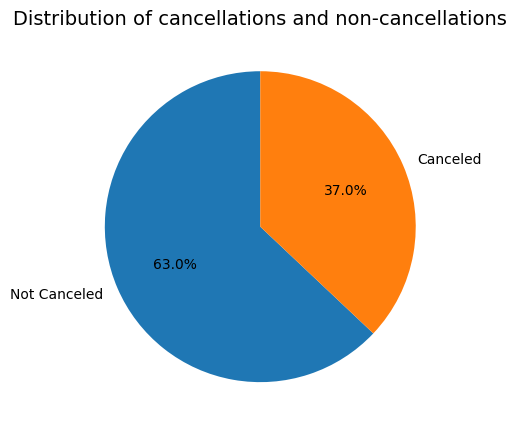

In [8]:
# Question: What is the breakdown of cancellations and non-cancellations
# Visualize the distribution of cancellation and non-cancellation
cancellation_counts = df['is_canceled'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cancellation_counts, labels=['Not Canceled', 'Canceled'], autopct='%1.1f%%', startangle=90)

plt.title('Distribution of cancellations and non-cancellations', fontsize=14)
plt.tight_layout()
plt.show()

### Analysis: Breakdown of Cancellations
The chart reveals that while **63.0%** of the bookings are successfully completed (not canceled), a substantial **37.0%** of all bookings end up being canceled. 

In the hospitality industry, a cancellation rate this high severely impacts revenue stability and room capacity planning. This finding strongly demands further investigations to identify the driving factors behind these cancellations (e.g., specific customer types, deposit policies, or lead times).

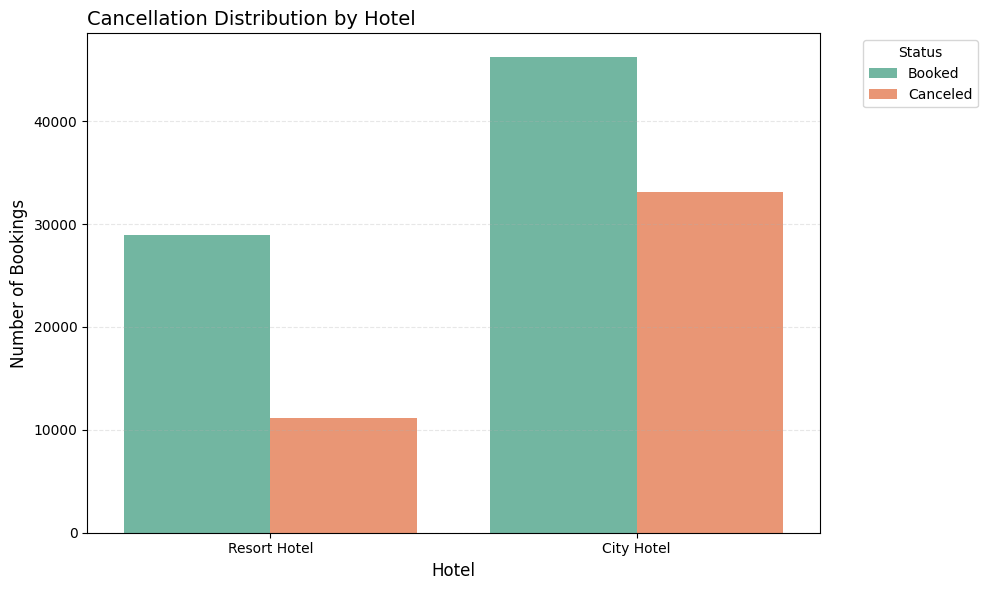

--Realtiv Cancellation Rate---
City Hotel: 41.73%
Resort Hotel: 27.76%


In [9]:
# Questions: Does the City Hotel or Resort Hotel has more cancellations? 
hotel_df = df.groupby('hotel')['is_canceled'].value_counts()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Hotel', fontsize=14, loc='left')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


print('--Realtiv Cancellation Rate---')
city_hotel = round(33102 / (46228 + 33102) * 100, 2)
resort_hotel = round(11122 / (28938 + 11122) * 100, 2)
print(f'City Hotel: {city_hotel}%')
print(f'Resort Hotel: {resort_hotel}%')

### Analysis of Cancellation Distribution by Hotel
* **City Hotel:** The chart illustrates that the City Hotel experiences a significantly higher volume of cancellations in absolute numbers. When looking at the ratio, the cancellation rate reaches roughly **41.73%** (approx. 33,000 cancellations out of 79,000 total bookings). This is exceptionally high and requires a deep-dive evaluation into the underlying reasons.
* **Resort Hotel:** In contrast, the Resort Hotel shows a healthier balance between confirmed and canceled bookings. With a cancellation rate of about **27.76%** (approx. 11,000 cancellations out of 40,000 total bookings), it proves to be more stable, which is typical for leisure travel where trips are planned further in advance and less likely to be dropped.

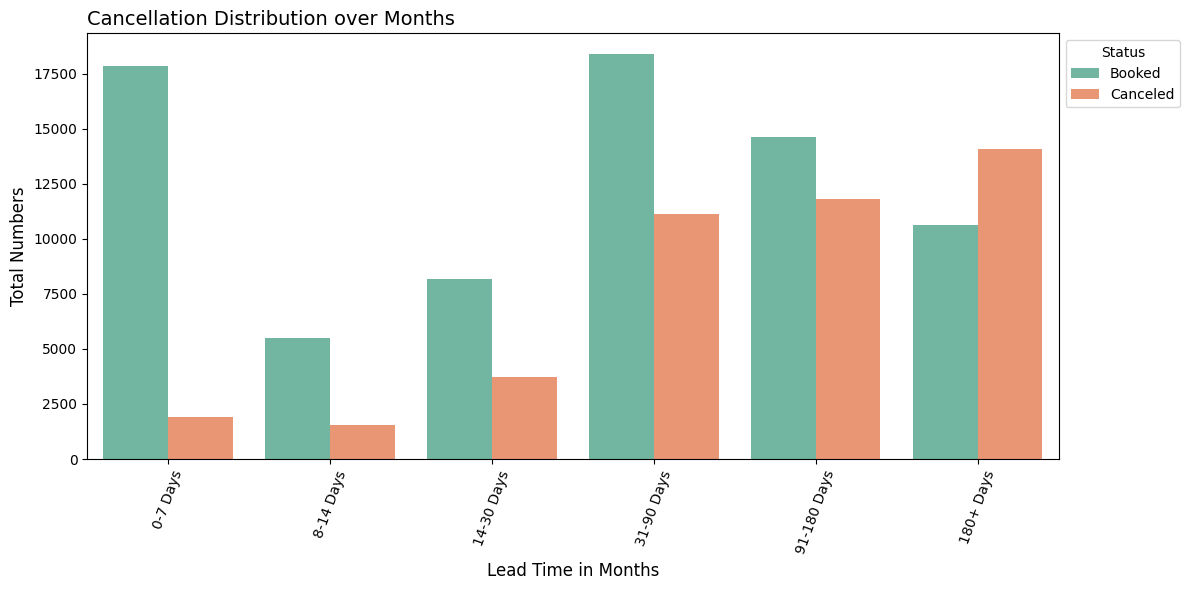

In [10]:
# Question: Is there a context between lead time and cancellation
# Analys with pd.cut to group the lead time days into months for better overview
month_bins = [-1, 7, 14, 30, 90, 180, float('inf')]
month_labels = ['0-7 Days', '8-14 Days', '14-30 Days', '31-90 Days', '91-180 Days', '180+ Days']

df['lead_time_group'] = pd.cut(df['lead_time'], bins=month_bins, labels=month_labels)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='lead_time_group', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution over Months', fontsize=14, loc='left')
plt.xlabel('Lead Time in Months', fontsize=12)
plt.ylabel('Total Numbers', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

### Analysis: Lead Time vs. Cancellations
* **Observation:** The chart clearly reveals that the majority of cancellations occur between 3 and 6 months prior to arrival. In contrast, bookings made 14 days to 1 month before arrival show very low cancellation rates. This indicates a high volatility in guest commitment during the 3-to-6-month window.
* **Business Recommendation:** To maximize occupancy and revenue, the hotel management should implement a strategic **overbooking policy** specifically targeting reservations made 3 to 6 months in advance. By factoring in this predictable cancellation wave, the hotel can ensure it remains closer to 100% capacity when the actual arrival date approaches.

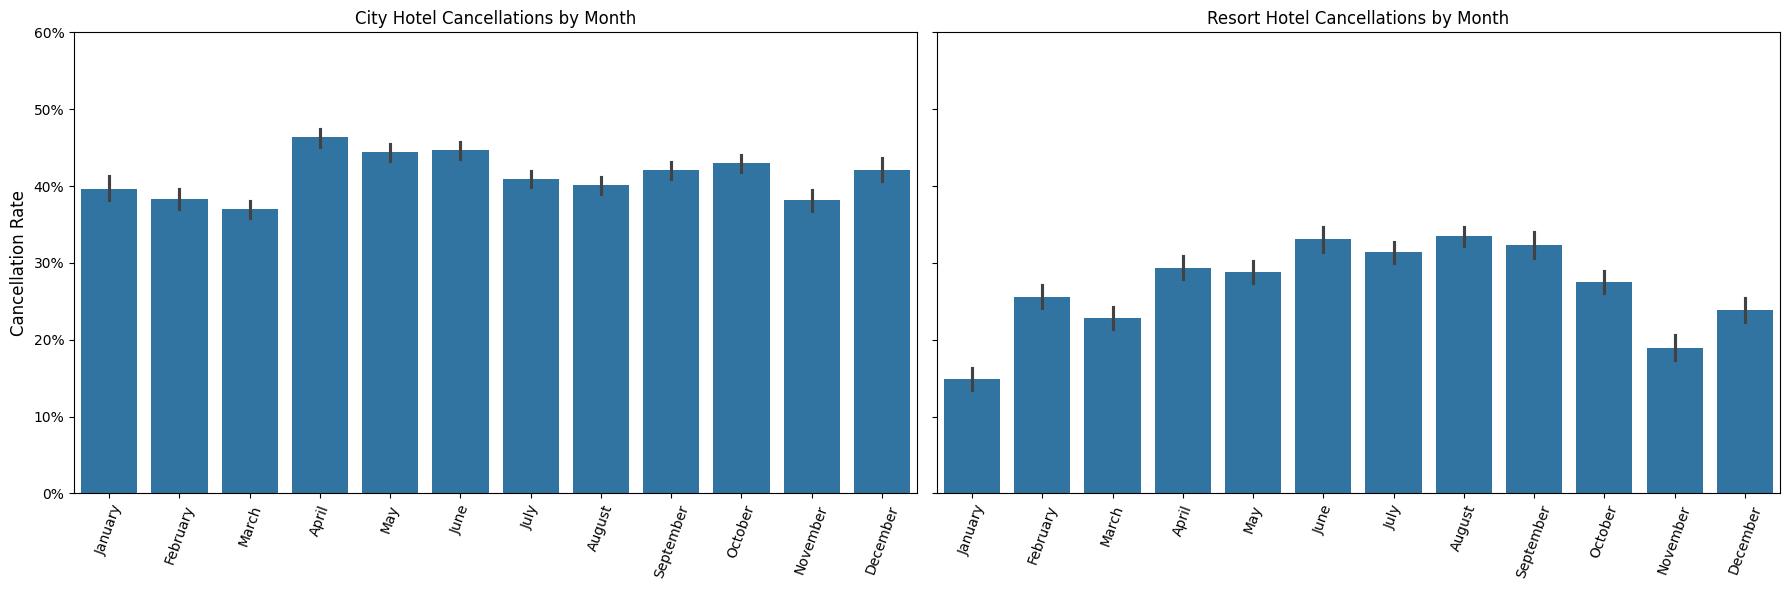

In [11]:
# Setting a months order instead of a-z
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
city_hotel_df = df[df['hotel'] == 'City Hotel']
resort_hotel_df =df[df['hotel'] == 'Resort Hotel']

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)
sns.barplot(data=city_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_title('City Hotel Cancellations by Month', fontsize=12)
axes[0].tick_params(axis='x', rotation=70)

axes[0].set_ylabel('Cancellation Rate', fontsize=12)
axes[0].set_ylim(0.0, 0.6)
axes[0].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
axes[0].set_yticklabels(['0%', '10%', '20%', '30%', '40%', '50%', '60%'])

sns.barplot(data=resort_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_title('Resort Hotel Cancellations by Month', fontsize=12)
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()


### Analysis: Cancellation Distribution by Month & Hotel
* **City Hotel (Structural Risk):** The chart reveals an alarming trend for the City Hotel, where the cancellation rate hovers consistently around **40% almost every single month**, regardless of the season. This indicates a deep structural issue—likely driven by business travelers or short-notice online bookings. Immediate operational actions, such as introducing non-refundable base rates or mandatory credit card pre-authorization, are required.
* **Resort Hotel (Seasonal Risk):** In contrast, the Resort Hotel shows a much healthier, classic seasonal distribution. Cancellations peak significantly during the **summer months (June, July, August, September), reaching up to 30%**. This reflects the volatile nature of holiday bookings, which are planned long in advance. 
* **Strategic Recommendation:** While the City Hotel needs a year-round, strict cancellation policy, the Resort Hotel should implement **dynamic seasonal restrictions**. For instance, during the high-season summer months, the hotel should enforce stricter deposit requirements (e.g., a 20% non-refundable deposit) to secure revenue against late cancellations.

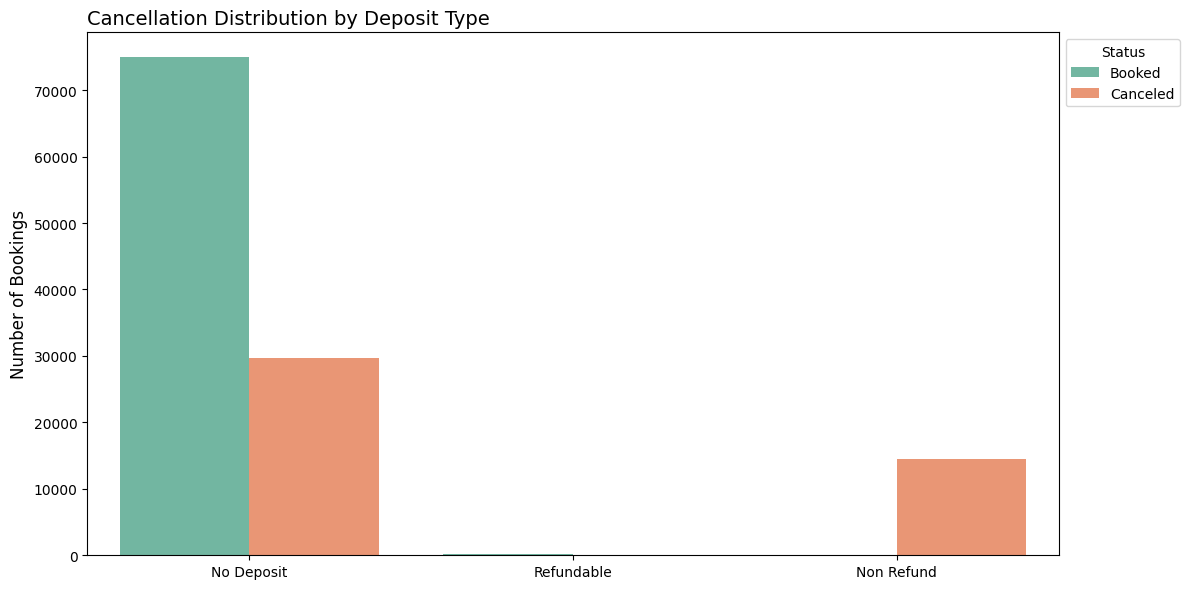

In [12]:
# Visualize the deposit type and cancellation distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='deposit_type', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Deposit Type', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])

plt.tight_layout()
plt.show()

### Analysis : Cancellation Distribution by Deposit Type
* **The Non-Refundable Paradox:** The chart reveals a massive, counter-intuitive anomaly: bookings with a **"Non Refund" policy have a cancellation rate of nearly 99%** (where `is_canceled = 1`). Intuitively, guests paying upfront without a refund option should be the least likely to cancel. This indicates a systemic issue—potentially driven by large travel agency group bookings (wholesalers blocking and dropping contingencies) or credit card fraud/chargeback patterns.
* **The Irrelevance of Refundable Rates:** "Refundable" deposits are practically non-existent in the dataset. Since this rate type generates neither significant bookings nor predictable revenue, hotel management should consider **deactivating this option entirely** to simplify the tariff structure and streamline distribution channels.
* **Main Business Volume:** The vast majority of bookings are made under the **"No Deposit"** policy. This is the hotel's main volume driver, showing a standard, expected cancellation split.

* **Strategic Recommendation:** 
  1. **Audit Distribution Channels:** Management must immediately audit which specific booking platforms or market segments the "Non Refund" bookings originate from. 
  2. **Fraud Prevention:** Implement stricter automated credit card pre-authorization and fraud checks at the time of booking to reduce malicious or volatile automated bookings.
  3. **Financial Investigation:** Further investigate if the "Non-Refundable" fees were actually collected by accounting or if these represent unrecovered revenue losses (e.g., due to successful chargebacks).

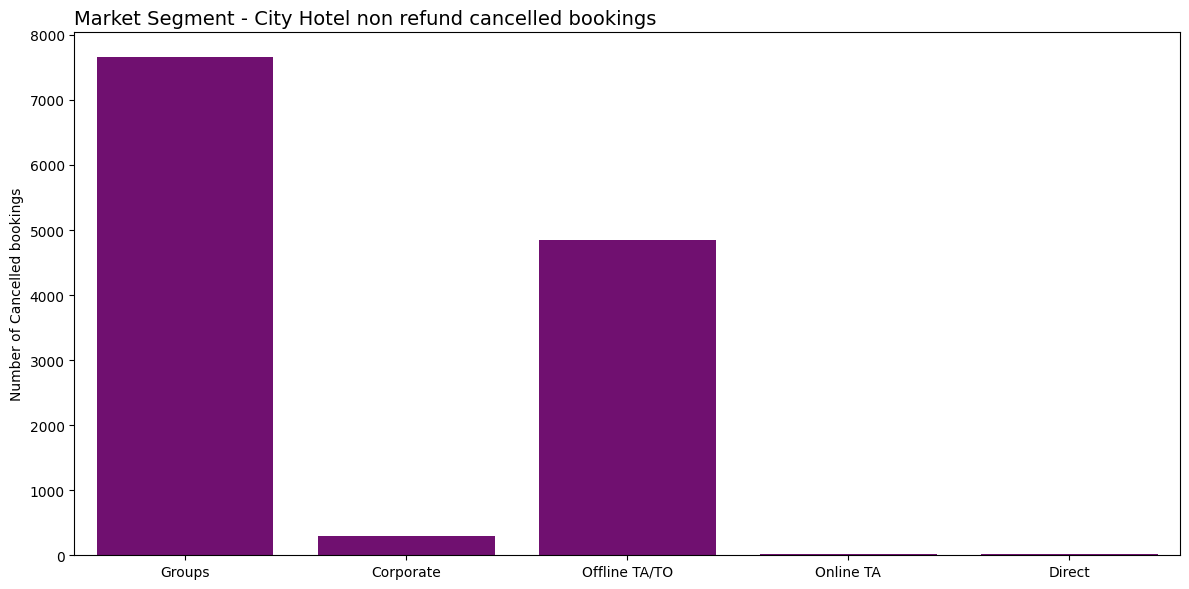

In [13]:
# Creating new variable for city hotel bookings which are cancelled and non refund
city_non_refund_df = df[(df['hotel'] == 'City Hotel') & (df['deposit_type'] == 'Non Refund') & (df['is_canceled'] == 1)]

# Checking the 'market segment' for this bookings
city_non_refund_df['market_segment'].value_counts()

plt.figure(figsize=(12,6))
sns.countplot(data=city_non_refund_df, x='market_segment', color='purple')
plt.title('Market Segment - City Hotel non refund cancelled bookings', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Number of Cancelled bookings')

plt.tight_layout()
plt.show()

### Analysis: Market Segment for cancelled 'non refund' bookings in the City Hotel
* The chart reveals that the majority of cancelled non-refundable bookings originate from the 'Groups' and 'Offline TA/TO' segments. This indicates that rooms are blocked and paid for upfront, but subsequently cancelled. Hotel management should investigate this specific anomaly, as it represents a potential risk for fraud or money laundering.

**Note:** Since the dataset lacks columns indicating whether cancelled bookings were actually refunded or if "no-show" fees were charged, a deeper financial investigation into these "non-refundable" bookings in the City Hotel is currently not possible based on this data alone.


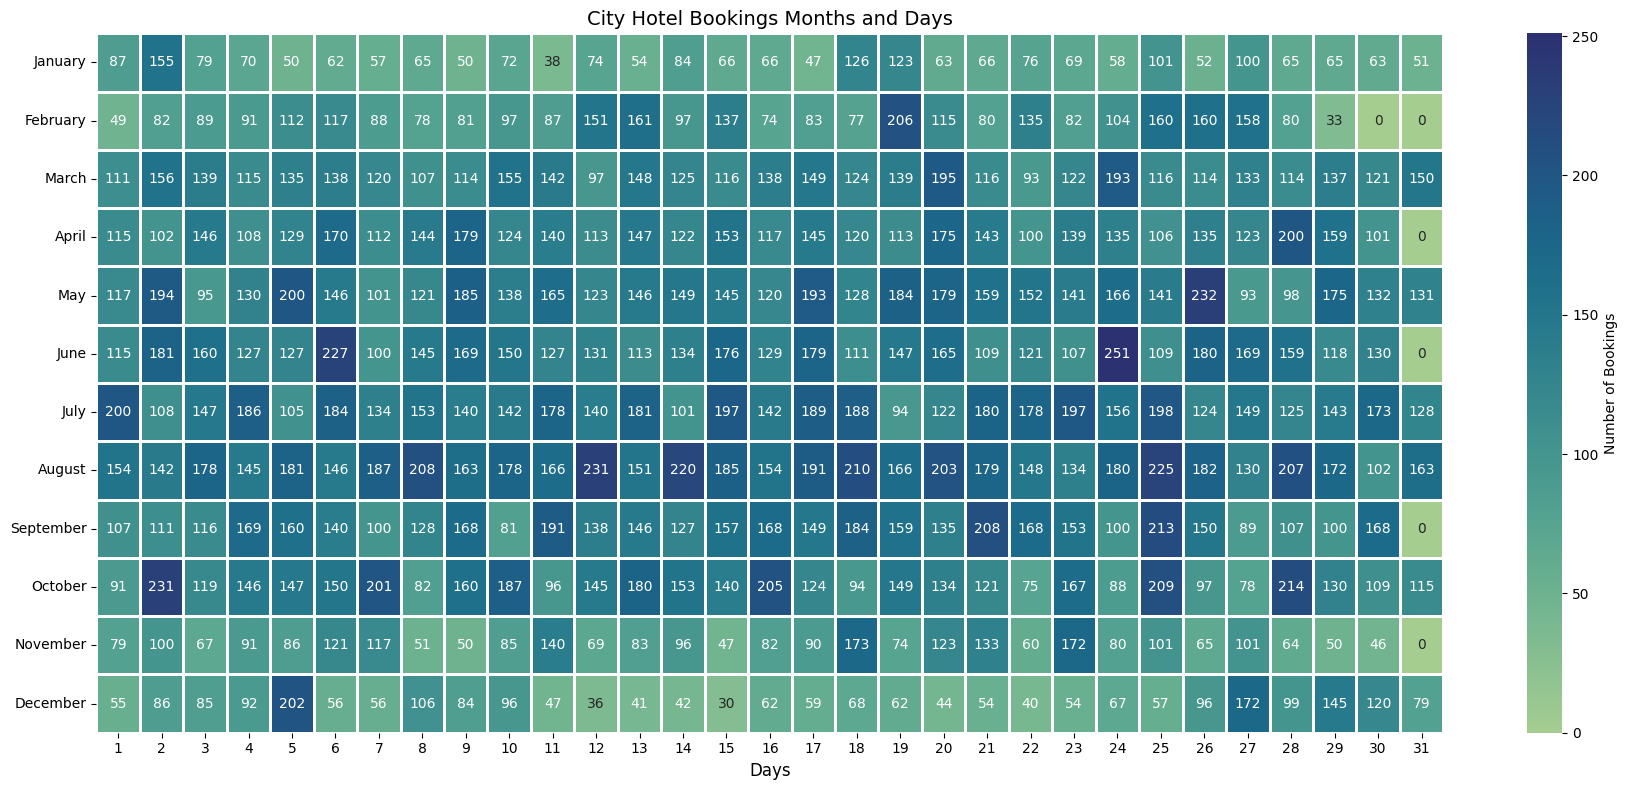

In [14]:
# Question: What are the typically high / low seasons of city hotel
# Creating heatmap for city hotel to check for high and low seasons
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
city_hotel_bookings = df[(df['hotel'] == 'City Hotel') & (df['is_canceled'] == 0)]

city_hotel_heatmap = city_hotel_bookings.pivot_table(index='arrival_date_month',
                                               columns='arrival_date_day_of_month', 
                                               values='is_canceled',
                                               aggfunc='count').fillna(0)
city_hotel_heatmap = city_hotel_heatmap.reindex(index=months_order)
plt.figure(figsize=(18,8))
sns.heatmap(data=city_hotel_heatmap, annot=True, cmap='crest', fmt='.0f', linewidths=1, cbar_kws={'label': 'Number of Bookings'})
plt.title('City Hotel Bookings Months and Days', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

### Analysis: City Hotel Bookings by Month and Day
* **Consistent Year-Round Demand:** The heatmap reveals that the City Hotel maintains a relatively stable and occupancy rate throughout most of the year. Unlike seasonal resort products, there are no extreme drops in booking volume, indicating a steady mix of business travelers and urban tourism.
* **Peak and Low Seasons:** A slight seasonal increase is visible during the high summer months of **July and August**, which represent the absolute peak periods. Conversely, the weakest performance occurs at the beginning of the year in **January and February**, which serves as the typical low season for city destinations.
* **Isolated Highs:** There are specific, isolated days showing spikes in demand (such as early December), which likely correlate with local events, conferences, or holiday tourism (e.g., Christmas markets).

* **Strategic Recommendation:** Since the base demand is stable year-round, hotel management should focus on **Dynamic Pricing** rather than seasonal promotions. During the stable months, revenue can be optimized by adjusting prices based on weekdays vs. weekends or major local events, while targeted promotions should be reserved strictly for the low-demand weeks in January and February.

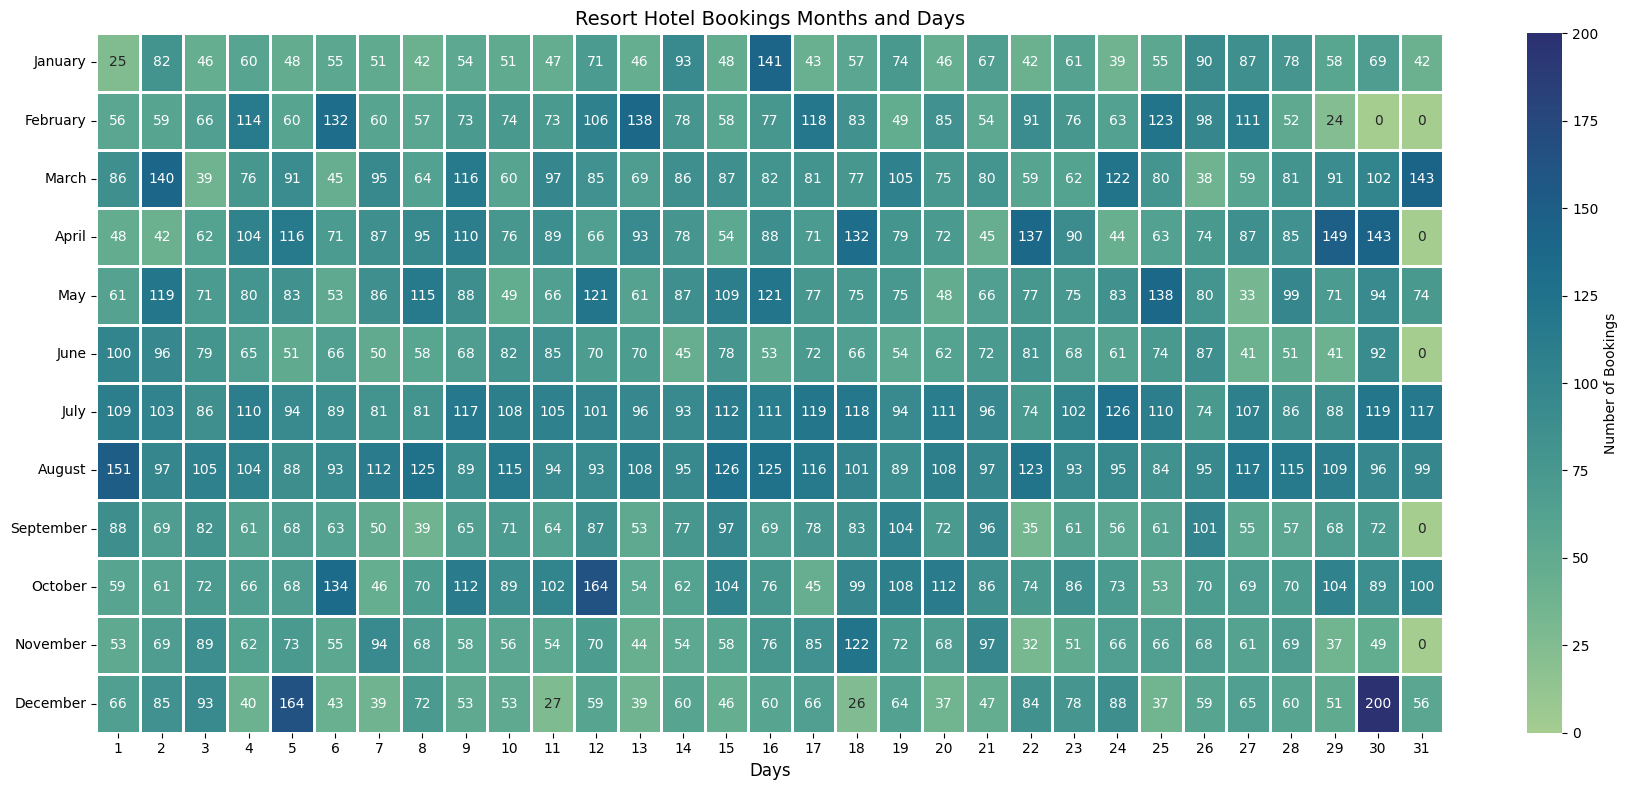

In [15]:
# Question: What are the typically high / low seasons of resort hotel
# Creating heatmap for resort hotel to check for high and low seasons
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
resort_hotel_bookings = df[(df['hotel'] == 'Resort Hotel') & (df['is_canceled'] == 0)]

resort_hotel_heatmap = resort_hotel_bookings.pivot_table(index='arrival_date_month',
                                               columns='arrival_date_day_of_month', 
                                               values='is_canceled',
                                               aggfunc='count').fillna(0)
resort_hotel_heatmap = resort_hotel_heatmap.reindex(index=months_order)
plt.figure(figsize=(18,8))
sns.heatmap(data=resort_hotel_heatmap, annot=True, cmap='crest', fmt='.0f', linewidths=1, cbar_kws={'label': 'Number of Bookings'})
plt.title('Resort Hotel Bookings Months and Days', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

### Analysis: Resort Hotel Bookings by Month and Day
* **Clear Seasonal Variance:** The heatmap reveals that the Resort Hotel is highly dependent on seasonality, driven almost entirely by leisure tourism. Unlike the City Hotel, the booking volume shows much more significant fluctuations between the summer and winter months.
* **Peak Summer Months:** A massive surge in successful bookings is visible during **July and August**, representing the absolute peak season for this resort destination. During this period, the hotel operates at maximum capacity across almost all days of the month.
* **Winter Low Season:** Conversely, the lowest booking volumes are recorded in **January and February**. This represents the classic off-season for a leisure resort, where demand drops significantly.

* **Strategic Recommendation:** Unlike the City Hotel, the Resort Hotel cannot rely on a stable year-round baseline demand. Management should implement a two-pronged strategy: **Premium Pricing** during the high-demand summer months (July/August) to maximize revenue, and aggressive **Seasonal Marketing Campaigns or Package Deals** (e.g., wellness or winter retreats) to stimulate demand and fill rooms during the quiet winter weeks in January and February.

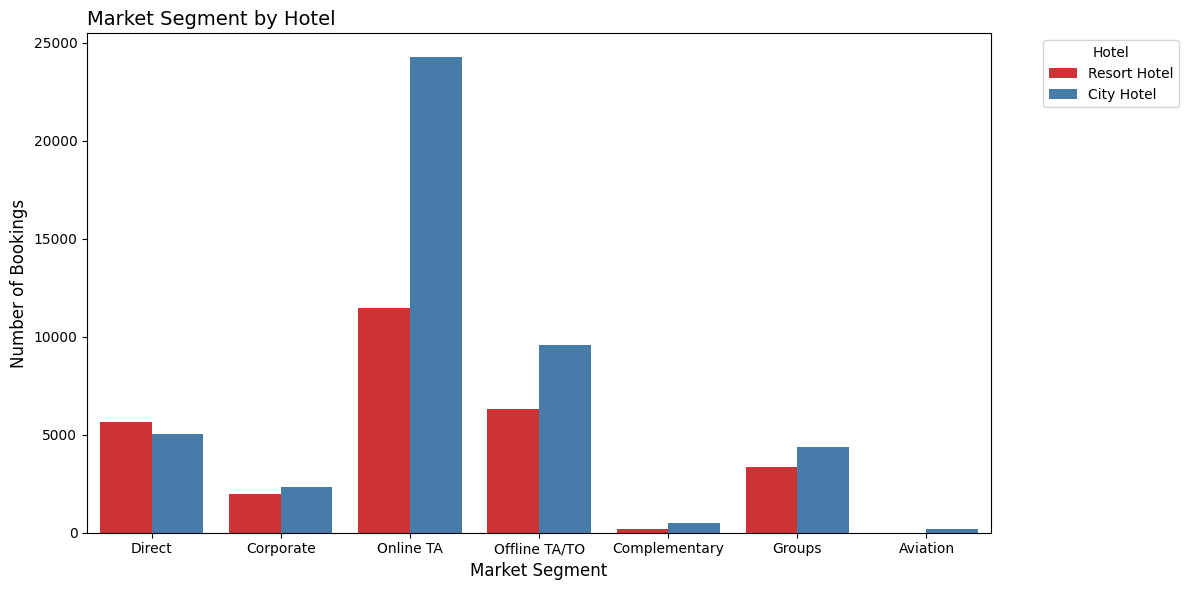

In [16]:
# Questions: What is the main market segment for each hotel
# Visualize the main market segment for each hotel
market_segment_bookings = df[df['is_canceled'] == 0]
plt.figure(figsize=(12,6))
sns.countplot(data=market_segment_bookings, x='market_segment', hue='hotel', palette='Set1')
plt.title('Market Segment by Hotel', fontsize=14, loc='left')
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Hotel')

plt.tight_layout()
plt.show()

### Analysis of the Market Segment for each Hotel:
* **City Hotel:** The chart reveals that the primary market segment for the City Hotel is "Online TA", which indicates that the majority of guests book their stays through online platforms. In contrast, direct bookings are relatively low. Hotel management should consider implementing special offers or loyalty incentives for direct bookings to reduce commission fees paid to third-party online agencies. Maximizing direct booking channels (such as the hotel website or telephone) helps protect profit margins by avoiding external fees.
* **Resort Hotel:** The Resort Hotel captures a higher share of direct bookings compared to the City Hotel. However, marketing efforts should still be optimized to further shift bookings from Online TA or Offline TA channels toward direct channels.
* **Aviation Segment:** Since the "Aviation" channel shows a negligible number of bookings, hotel management should evaluate whether it is worth maintaining or if resources should be reallocated elsewhere.

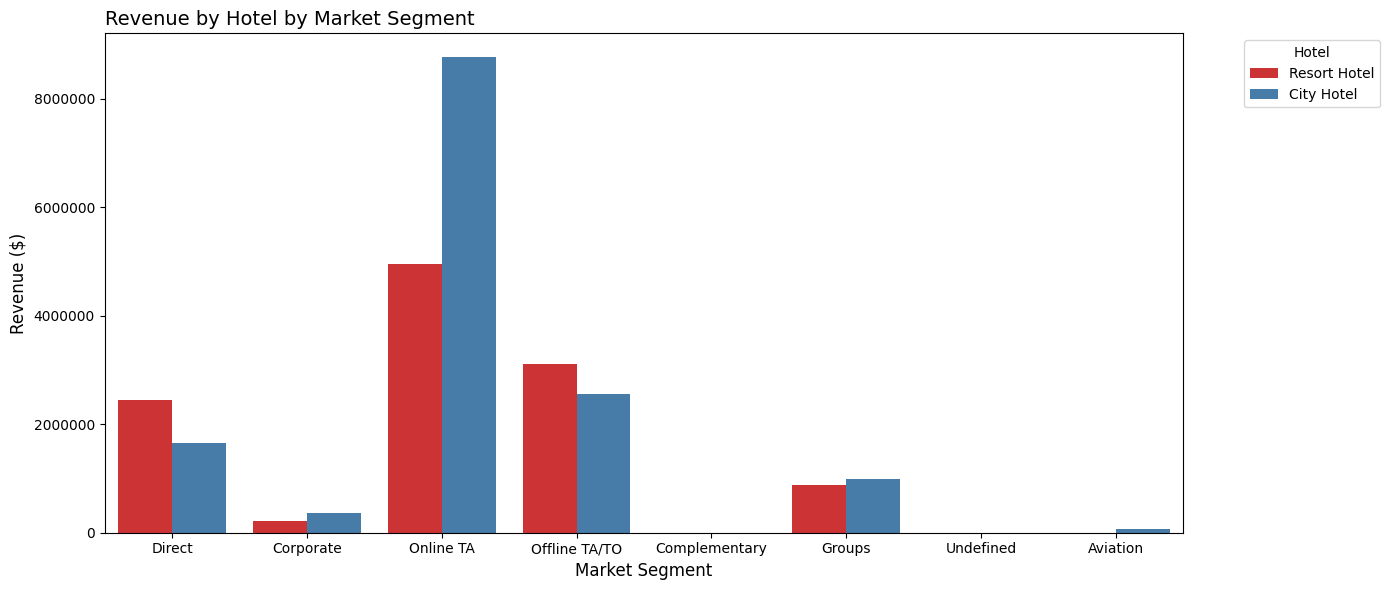

In [17]:
# Questions: What is the revenue generated by each market segment
# Creating new column to accumulate stays in weekend nights and week nights from bookings which are not cancelled
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = np.where(df['is_canceled'] == 0, df['total_nights'] * df['adr'], 0)

plt.figure(figsize=(14,6))
sns.barplot(data=df, x='market_segment', y='revenue', estimator='sum', hue='hotel', palette='Set1', errorbar=None)
plt.title('Revenue by Hotel by Market Segment', fontsize=14, loc='left')
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Hotel')
plt.tight_layout()
plt.show()

In [18]:
avg_per_market_segment = df.groupby(['hotel', 'market_segment'])['revenue'].mean().reset_index().round(2)
print(avg_per_market_segment)

           hotel market_segment  revenue
0     City Hotel       Aviation   299.02
1     City Hotel  Complementary     5.06
2     City Hotel      Corporate   122.46
3     City Hotel         Direct   272.07
4     City Hotel         Groups    70.18
5     City Hotel  Offline TA/TO   152.51
6     City Hotel      Online TA   226.14
7     City Hotel      Undefined     0.00
8   Resort Hotel  Complementary    10.30
9   Resort Hotel      Corporate    91.92
10  Resort Hotel         Direct   374.92
11  Resort Hotel         Groups   152.21
12  Resort Hotel  Offline TA/TO   415.62
13  Resort Hotel      Online TA   279.31


### Analysis of Revenue by Market Segment and Hotel:
* **Online TA Dominates Total Revenue:** The chart demonstrates that for both hotel types, the "Online TA" (Online Travel Agency) segment generates the vast majority of total revenue. This is driven by the sheer volume of bookings coming through these platforms.
* **The Direct Booking Premium (City Hotel):** Interestingly, looking at the average revenue per booking reveals a different story. In the City Hotel, the average revenue for direct bookings is **$272.07**, whereas Online TA bookings average **$226.14**. Despite the lower booking volume, direct guests spend more on average per stay. 
* **The Resort Hotel Pricing:** A similar pattern is visible for the Resort Hotel, where direct bookings also command a healthy average revenue, proving that direct customers are highly valuable across both properties.

* **Strategic Recommendation (Pricing & Commissions):** Since online agencies charge substantial commission and agency fees (often between 15% and 25%), hotel management is losing significant profit margins on Online TA volume. 
  1. **Dynamic Pricing Adjustment:** Management should consider increasing room rates on Online TA platforms to pass the commission costs onto the consumer.
  2. **Direct Booking Incentives:** Simultaneously, they should offer slight discounts or exclusive perks (e.g., free breakfast, late check-out) for direct bookings on the hotel website. Since direct bookings incur no middleman fees, the hotel can easily absorb a small discount and still come out with a higher net profit margin than an Online TA booking.

In [19]:
# Check for Market Segment 'undefined'
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [20]:
# Replacing undefined market segment into online ta
df['market_segment'] = df['market_segment'].replace('Undefined', 'Online TA')

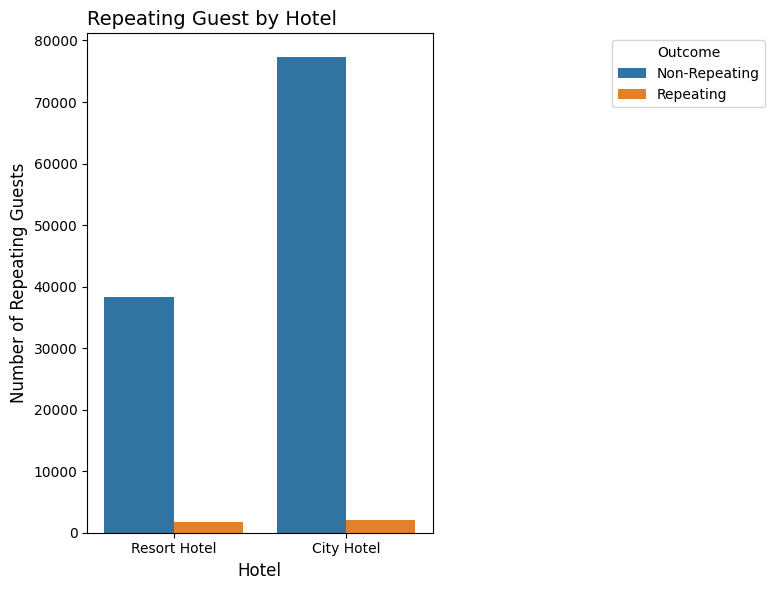

In [21]:
# Question: Does both hotels have repeating guests? 
# Checking for each hotel the repeating guest
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hotel', hue='is_repeated_guest')
plt.title('Repeating Guest by Hotel', fontsize=14, loc='left')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Number of Repeating Guests', fontsize=12)
plt.legend(bbox_to_anchor=(1.5, 1), loc='upper left', title='Outcome', labels=['Non-Repeating', 'Repeating'])

plt.tight_layout()
plt.show()

### Analysis of Repeating Guests by Hotel:
* **Predominance of First-Time Visitors:** The chart clearly reveals that the vast majority of bookings for both the City Hotel and the Resort Hotel come from non-repeating guests (first-time visitors). 
* **Critical Retention Insight:** This low proportion of returning customers serves as a significant warning sign for hotel management. It indicates a potential gap in customer loyalty or post-stay engagement.
* **Strategic Recommendations:**
    1. **Investigate Guest Satisfaction:** Management should investigate guest satisfaction metrics, online reviews, and post-stay surveys to determine why the retention rate is so low (e.g., service issues, pricing, or lack of competitive advantage).
    2. **Loyalty Marketing Actions:** Implementing targeted retention strategies—such as establishing a loyalty rewards program, sending automated email offers to past guests, or providing exclusive return-discounts—could help reduce customer acquisition costs and increase the share of repeating guests.

## Final Analysis and Key Insights

### 1. Cancellation Performance & Risk Assessment
* **High Baseline Cancellations:** Across the entire dataset, the overall cancellation rate stands at 37%. This represents a significant operational and revenue challenge that requires immediate management attention to stabilize occupancy forecasting.
* **Lead Time Trends:** The analysis indicates that the majority of these cancellations occur 3 to 6 months prior to the scheduled arrival date, providing a window for potential overbooking or re-marketing strategies.
* **City Hotel Vulnerability:** The City Hotel is particularly affected, with a relative cancellation rate of 41.73%—meaning nearly two out of every five bookings fail to materialize. This high volatility warrants further investigation into booking source reliability.
* **Non-Refundable Anomalies:** A critical pattern emerged showing that almost all "Non-Refund" bookings in the City Hotel resulted in cancellations. In a standard hospitality context, this is highly unusual and could flag systemic issues, potential fraudulent activity, or payment processing gaps. However, due to data limitations, it cannot be verified whether cancellation fees were successfully collected or if the deposits were fully refunded.

### 2. Distribution Channels & Pricing Strategy
* **OTAs vs. Direct Bookings:** The vast majority of bookings across both properties are generated via Online Travel Agencies (OTAs), driven by lower price points compared to direct channels. 
* **Revenue Strategy Optimization:** To mitigate high commission fees and improve profit margins, the Revenue Management team should restructure the pricing strategy. Implementing lower rates or exclusive perks for direct bookings, while increasing OTA rates to absorb commission costs, would incentivize guests to book directly.

### 3. Customer Loyalty & Retention
* **Low Repeat Volume:** The proportion of returning customers is exceptionally low across both hotels. Management needs to investigate whether this is driven by gaps in guest satisfaction, lack of post-stay engagement, or missing loyalty incentives. 

# Feature Engineering

In [22]:
# Filling missing child values 
# Checking the missing values in the column child - which hotel 
print(df[df['children'].isna()])

            hotel  is_canceled  lead_time  arrival_date_year  \
40600  City Hotel            1          2               2015   
40667  City Hotel            1          1               2015   
40679  City Hotel            1          1               2015   
41160  City Hotel            1          8               2015   

      arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
40600             August                        32                          3   
40667             August                        32                          5   
40679             August                        32                          5   
41160             August                        33                         13   

       stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
40600                        1                     0       2  ...   
40667                        0                     2       2  ...   
40679                        0                     2       3  ... 

**Note on Missing Values (Children):**

The analysis revealed 4 missing records in the `children` column, all originating from the City Hotel segment. To handle these missing values without distorting the distribution, the mode (most frequent value) for the `children` column within the City Hotel segment will be calculated and utilized to impute the empty entries.

In [23]:
# Creating variable for city hotel and children mode
mode_child_city = df[df['hotel'] == 'City Hotel']['children'].mode()[0]

# Filling missing children values with the City Hotel mode
df['children'] = df['children'].fillna(mode_child_city)

# Checking on missing values again
print(df.isna().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               0
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [24]:
# Checking the unique values for column 'agent'
print(df['agent'].unique())

[ nan 304. 240. 303.  15. 241.   8. 250. 115.   5. 175. 134. 156. 243.
 242.   3. 105.  40. 147. 306. 184.  96.   2. 127.  95. 146.   9. 177.
   6. 143. 244. 149. 167. 300. 171. 305.  67. 196. 152. 142. 261. 104.
  36.  26.  29. 258. 110.  71. 181.  88. 251. 275.  69. 248. 208. 256.
 314. 126. 281. 273. 253. 185. 330. 334. 328. 326. 321. 324. 313.  38.
 155.  68. 335. 308. 332.  94. 348. 310. 339. 375.  66. 327. 387. 298.
  91. 245. 385. 257. 393. 168. 405. 249. 315.  75. 128. 307.  11. 436.
   1. 201. 183. 223. 368. 336. 291. 464. 411. 481.  10. 154. 468. 410.
 390. 440. 495. 492. 493. 434.  57. 531. 420. 483. 526. 472. 429.  16.
 446.  34.  78. 139. 252. 270.  47. 114. 301. 193. 182. 135. 350. 195.
 352. 355. 159. 363. 384. 360. 331. 367.  64. 406. 163. 414. 333. 427.
 431. 430. 426. 438. 433. 418. 441. 282. 432.  72. 450. 180. 454. 455.
  59. 451. 254. 358. 469. 165. 467. 510. 337. 476. 502. 527. 479. 508.
 535. 302. 497. 187.  13.   7.  27.  14.  22.  17.  28.  42.  20.  19.
  45. 

In [25]:
# Checking the unique values for column 'company'
print(df['company'].unique())

[ nan 110. 113. 270. 178. 240. 154. 144. 307. 268.  59. 204. 312. 318.
  94. 174. 274. 195. 223. 317. 281. 118.  53. 286.  12.  47. 324. 342.
 373. 371. 383.  86.  82. 218.  88.  31. 397. 392. 405. 331. 367.  20.
  83. 416.  51. 395. 102.  34.  84. 360. 394. 457. 382. 461. 478. 386.
 112. 486. 421.   9. 308. 135. 224. 504. 269. 356. 498. 390. 513. 203.
 263. 477. 521. 169. 515. 445. 337. 251. 428. 292. 388. 130. 250. 355.
 254. 543. 531. 528.  62. 120.  42.  81. 116. 530. 103.  39.  16.  92.
  61. 501. 165. 291. 290.  43. 325. 192. 108. 200. 465. 287. 297. 490.
 482. 207. 282. 437. 225. 329. 272.  28.  77. 338.  72. 246. 319. 146.
 159. 380. 323. 511. 407. 278.  80. 403. 399.  14. 137. 343. 346. 347.
 349. 289. 351. 353.  54.  99. 358. 361. 362. 366. 372. 365. 277. 109.
 377. 379.  22. 378. 330. 364. 401. 232. 255. 384. 167. 212. 514. 391.
 400. 376. 402. 396. 302. 398.   6. 370. 369. 409. 168. 104. 408. 413.
 148.  10. 333. 419. 415. 424. 425. 423. 422. 435. 439. 442. 448. 443.
 454. 

**Note on Missing Values (Agent and Company):**

The `agent` and `company` columns contain numeric ID values. Since valid IDs start at 1 and no existing values are below 1, missing values are interpreted as bookings without an associated agent or company. Therefore, the missing values are filled with 0 to keep the columns numeric and to represent "no agent" or "no company".

In [26]:
# Missing values in `agent` and `company` indicate that no agent or company was involved. Since valid IDs start at 1 and no existing values are below 1, missing values are filled with 0.
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Check for missing values
print(df.isna().sum())

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            0
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
agent                               0
company                             0
days_in_waiting_list                0
customer_typ

In [27]:
# Filling missing 'country' values will UNK for unknown
df['country'] = df['country'].fillna('UNK')

# Checking for missing values
print(df.isna().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

**Note:** All missing values across the dataset have been successfully handled and imputed. The data contains no further null values and is ready for the next feature engineering steps.

In [28]:
# Implement cols for total pax
df['total_pax'] = df['adults'] + df['children'] + df['babies']
df['total_pax'] = df['total_pax'].astype(int)

In [29]:
# Implement col for roomtyp changes
df['room_type_changes'] = (df['reserved_room_type'] != df['assigned_room_type'] ).astype(int)

In [30]:
# Change Agent and company into binary features
df['has_agent'] = (df['agent'] != 0).astype(int)
df['has_company'] = (df['company'] != 0).astype(int)
df = df.drop(columns=['company', 'agent'])

In [31]:
# Splitting the Countries into regions to avoid to much columns for ML
europe_codes = [
        'GBR', 'FRA', 'ESP', 'DEU', 'ITA', 'IRL', 'BEL', 'NLD', 
        'CHE', 'AUT', 'SWE', 'POL', 'ISR', 'NOR']
    
df['country_region'] = 'International'
df.loc[df['country'].isin(europe_codes), 'country_region'] = 'Europe'
df.loc[df['country'] == 'PRT', 'country_region'] = 'Domestic'

df = pd.get_dummies(df, columns=['country_region'], dtype=int)

df = df.drop(columns=['country'])

In [32]:
# Check of cols
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'market_segment', 'distribution_channel', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'reserved_room_type', 'assigned_room_type', 'booking_changes',
       'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card', 'lead_time_group', 'total_nights',
       'revenue', 'total_pax', 'room_type_changes', 'has_agent', 'has_company',
       'country_region_Domestic', 'country_region_Europe',
       'country_region_International'],
      dtype='object')

In [33]:
# Check for Distribution Channel 'undefined'
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [34]:
# Replacing the 5 undefined market segments into TA/TO - to the most comun
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', 'TA/TO')

In [35]:
df['meal'].value_counts()

meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

**Note:** There are **1,169 bookings** where the meal type is listed as `Undefined`. 
I will keep these values as `Undefined` rather than imputing them with the most frequent value (`BB` / Bed & Breakfast).

In [36]:
# Encode cols for ML
columns_to_encode = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
df = pd.get_dummies(df, columns=columns_to_encode, dtype=int)

In [37]:
# Drop unnecessary cols
cols_to_drop = ['revenue','room_type_changes','arrival_date_year', 'reservation_status', 'reservation_status_date', 'lead_time_group', 'reserved_room_type', 'assigned_room_type', 'arrival_date_month', 'name', 'email', 'phone-number', 'credit_card']
df = df.drop(columns=cols_to_drop)

In [38]:
# Final Check of all cols
df.columns

Index(['is_canceled', 'lead_time', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_nights', 'total_pax', 'has_agent',
       'has_company', 'country_region_Domestic', 'country_region_Europe',
       'country_region_International', 'hotel_City Hotel',
       'hotel_Resort Hotel', 'meal_BB', 'meal_FB', 'meal_HB', 'meal_SC',
       'meal_Undefined', 'market_segment_Aviation',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'distribution_channel_Corporate', 'distribution_channel_Direct',
       'distribution_channel_

# Machine Learning and Prediction

In [39]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [40]:
# Splitting dataset into X the features and y the target
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

In [41]:
# Implement train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42,
                                                     stratify = y
                                                    )

In [42]:
# Check for the shape of x and y
print(f'Rows: {X_train.shape[0]} -- Columns: {X_train.shape[1]}')
print(f'Rows: {y_train.shape[0]}')

Rows: 95512 -- Columns: 48
Rows: 95512


In [43]:
# Implement RandomForest Model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
# Make Prediction with the trained model
rf_model_pred = rf_model.predict(X_test)

# Check for accuracy 
rf_accuracy = accuracy_score(y_test, rf_model_pred)

print(f'Score: {rf_accuracy*100:.2f}%')
print("\nClassification Report:")
print(classification_report(y_test,rf_model_pred))

Score: 87.99%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     15033
           1       0.87      0.79      0.83      8845

    accuracy                           0.88     23878
   macro avg       0.88      0.86      0.87     23878
weighted avg       0.88      0.88      0.88     23878



In [45]:
# Check the model feature importance
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_imp_df.sort_values(by='Importance', ascending=False).head())

                      Feature  Importance
0                   lead_time    0.140663
13                        adr    0.097601
42    deposit_type_Non Refund    0.080719
1    arrival_date_week_number    0.075533
2   arrival_date_day_of_month    0.071028
